In [2]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.impute import SimpleImputer

# Exploratory Data Analysis and Data Cleaning

In [3]:
# read the data
dataset=pd.read_csv('heart.csv')
# dataset = pd.read_csv(r"D:\Downloads\Machine_Learning_Projects\heart_disease_prediction")


In [4]:
dataset.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0


In [5]:
dataset.shape

(1025, 14)

In [6]:
# check fro missing values
(dataset.isnull().sum().sort_values(ascending=False)/dataset.shape[0])*100
# dataset.isnull().sum().sort_values(ascending=False)

age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64

In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# now check target column
dataset['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [10]:
dataset['target'].unique()

array([0, 1])

In [11]:
dataset['target'].nunique()

2

In [12]:
# now check data types
dataset.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [13]:
# pd.set_option('display.max_columns',26)

In [14]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Preprocessing

**` Now separate features and target(output)`**

In [15]:
x=dataset.drop(columns='target')

In [16]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


**`1-------> hd(heart disease)`**
**`0------->nothd (no heart disease)`**



In [17]:
# y=dataset['classification']
y=dataset.iloc[:,-1]

In [18]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

**`Train test split`**



In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,stratify=y,test_size=.20)

In [20]:
x.shape,x_train.shape,x_test.shape

((1025, 13), (820, 13), (205, 13))

In [21]:
y.shape,y_train.shape,y_test.shape

((1025,), (820,), (205,))

**`Now make transformer for cat and numerical features`**

In [22]:
# Auto feature selection
num_features = x.columns.tolist()
print(num_features)

# Pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features)
])

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


# Model training and Evaluation

In [23]:
# now combine preprocessor and model to get final pipeline
pipeline=Pipeline([
    ('preprocessor',preprocessor),
  ('model',RandomForestClassifier(random_state=42))
])

In [24]:
# now train the model
pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

In [25]:
pipeline.score(x_train,y_train)*100,pipeline.score(x_test,y_test)*100

(100.0, 100.0)

**`Now evaluate the model`**

In [26]:
y_pred=pipeline.predict(x_test);

In [27]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [28]:
# print confusion matrix to analyse
cm=confusion_matrix(y_test,y_pred)
print(cm)
# sns.heatmap(cm, annot=True,cmap='Blues',square=True,linecolor='black',linewidth=2,cbar=False)
# plt.xlabel("Predicted label")
# plt.ylabel("True label")
# plt.title("Confusion Matrix")
# plt.show()

[[100   0]
 [  0 105]]


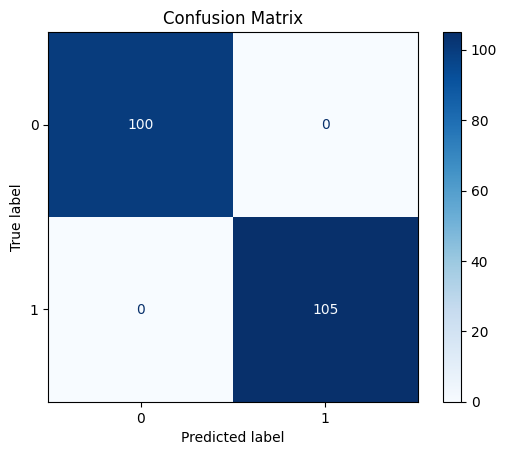

In [29]:
# display confusion

ConfusionMatrixDisplay.from_estimator(pipeline,x_test,y_test,cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [30]:
model=RandomForestClassifier(random_state=42);


In [31]:
print(f"The accuracy_score of {model} = ",accuracy_score(y_test,y_pred)*100)
print(f"\nThe precision_score of {model} = ",precision_score(y_test,y_pred)*100)
print(f"\nThe recall_score of {model} = ",recall_score(y_test,y_pred)*100)
print(f"\nThe f1_score of {model} = ",f1_score(y_test,y_pred)*100)
print(f"\nThe cross_val_score of {model} = ",cross_val_score(pipeline,x,y)*100)
print(f"\nThe mean cross_val_score of {model} = ",cross_val_score(pipeline,x,y).mean()*100)

The accuracy_score of RandomForestClassifier(random_state=42) =  100.0

The precision_score of RandomForestClassifier(random_state=42) =  100.0

The recall_score of RandomForestClassifier(random_state=42) =  100.0

The f1_score of RandomForestClassifier(random_state=42) =  100.0

The cross_val_score of RandomForestClassifier(random_state=42) =  [100.         100.         100.         100.          98.53658537]

The mean cross_val_score of RandomForestClassifier(random_state=42) =  99.70731707317073


**`So the mean accuracy of model is 99%`**

In [32]:
# # preprocess x and then check missing value
# x_filled=pipeline.named_steps['preprocessor'].fit_transform(x)
# print(pd.DataFrame(x_filled).isnull().sum().sum())
# print(pd.DataFrame(x_filled).isnull().sum())

In [33]:
from sklearn.compose import make_column_selector

# Get feature names after transformation
feature_names=pipeline.named_steps['preprocessor'].get_feature_names_out()

print("Number of final features:", len(feature_names))
print("Feature names:", feature_names)


Number of final features: 13
Feature names: ['num__age' 'num__sex' 'num__cp' 'num__trestbps' 'num__chol' 'num__fbs'
 'num__restecg' 'num__thalach' 'num__exang' 'num__oldpeak' 'num__slope'
 'num__ca' 'num__thal']


# Make Predictive system

In [34]:
import pandas as pd

# Your input (without target)
user_input = (34,0,1,118,210,0,1,192,0,0.7,2,0,2)

# Convert to DataFrame
user_input_df = pd.DataFrame([user_input], columns=x.columns)

# Prediction
prediction = pipeline.predict(user_input_df)
prob = pipeline.predict_proba(user_input_df)[0][1]

# Output
if prediction[0] == 1:
    print(f"🚨 Patient has Heart Disease.")
else:
    print(f"✅ Patient has no Heart Disease.")

🚨 Patient has Heart Disease.


**`Now save the model`**

In [35]:
import joblib

In [36]:
# save model and feature names
heart_bundle={
    "pipeline":pipeline,
    "features_names":x.columns.to_list()
}
joblib.dump(heart_bundle,"heart_model_bundle.joblib")

['heart_model_bundle.joblib']